Loading data...
Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Customers: (99441, 5)
Payments: (103886, 5)
Reviews: (99224, 7)

DATA CLEANING
Merged dataset shape: (115038, 30)

Missing values:
order_approved_at                  15
order_delivered_carrier_date        2
order_delivered_customer_date       8
product_category_name            1628
product_name_lenght              1628
product_description_lenght       1628
product_photos_qty               1628
product_weight_g                   20
product_length_cm                  20
product_height_cm                  20
product_width_cm                   20
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
dtype: int64

KEY PERFORMANCE INDICATORS
Total Revenue: $13,813,963.68
Total Orders: 96,478
Total Customers: 96,478
Total Sellers: 2,970
Average Order Value: $143.18

SAVING CLEANED DATASETS
✅ Saved merged dataset to: 

C:\Users\Raina Khan\AppData\Local\Temp\ipykernel_13180\3157524255.py:127: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



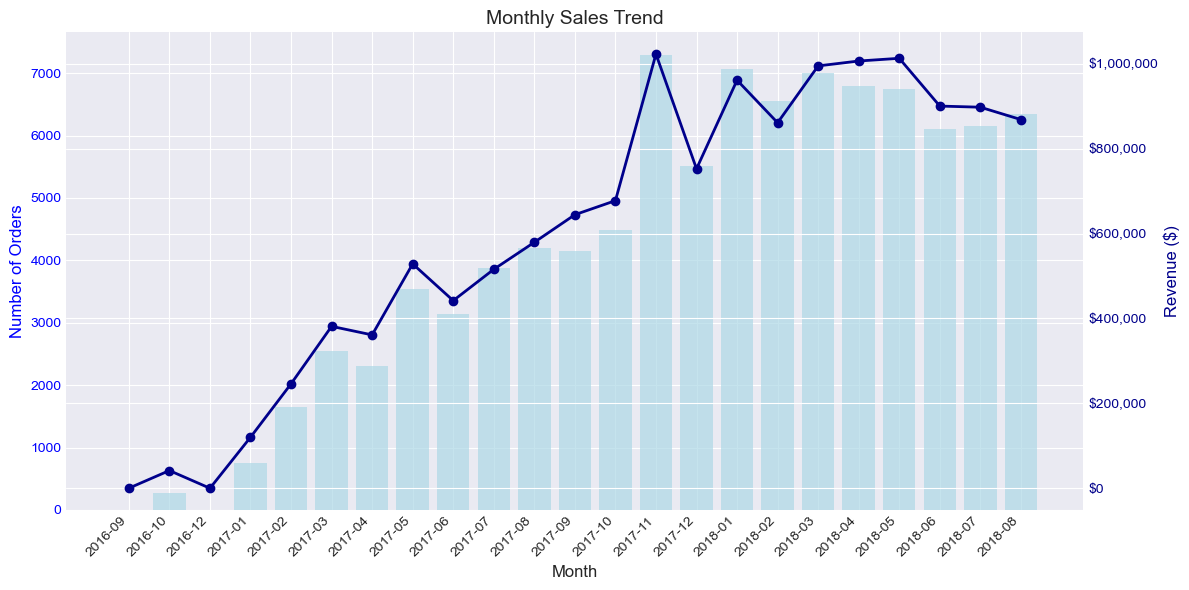

✅ Translation loaded


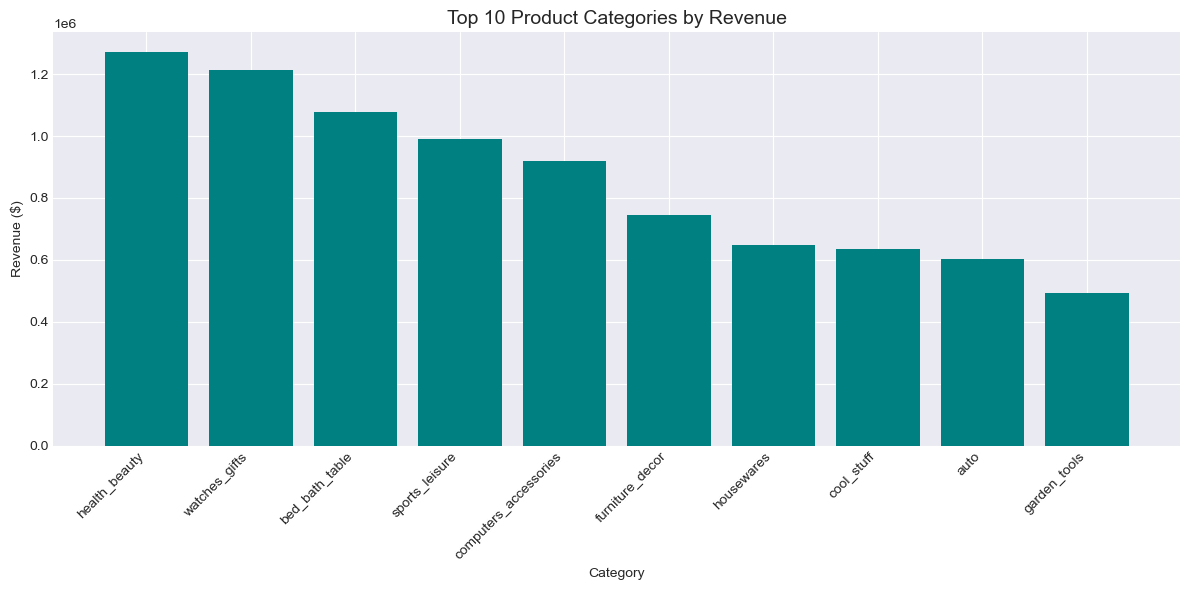

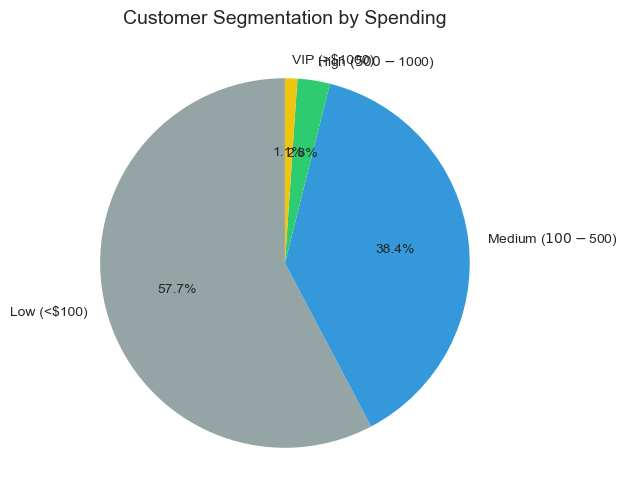

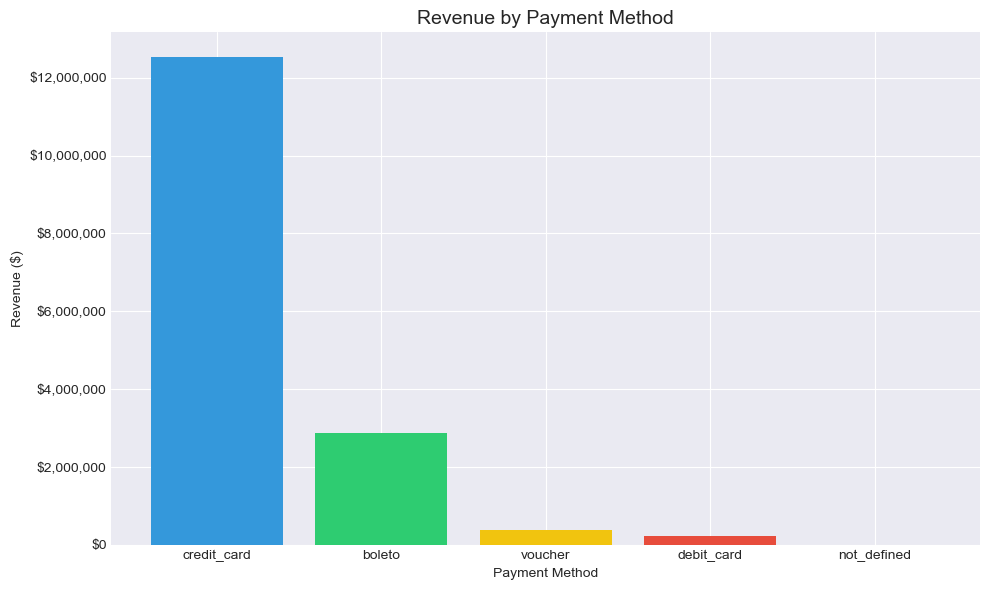

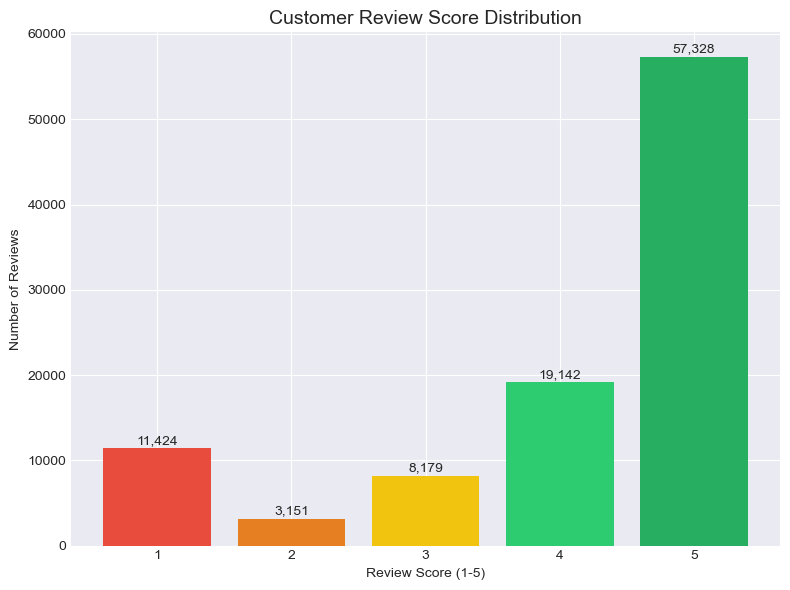


✅ All visualizations saved successfully to '../screenshots/' folder!

KEY INSIGHTS

1. Sales Trends:
   - Peak sales during November (likely Black Friday effect)
   - Consistent growth pattern over the period

2. Top Categories:
   - Health & Beauty, Watches & Gifts, and Computers are top revenue generators
   - These categories should be prioritized for marketing and inventory

3. Customer Segmentation:
   - VIP customers (>$1000) represent small percentage but drive significant revenue
   - Medium spenders ($100-$500) are the largest segment

4. Payment Preferences:
   - Credit cards are the most used payment method
   - Installment payments are popular for higher-value purchases

5. Customer Satisfaction:
   - Majority of reviews are 4-5 stars
   - Only 10% of reviews are 1-2 stars (low satisfaction)


BUSINESS RECOMMENDATIONS

1. Marketing Strategy:
   - Target VIP customers with loyalty programs
   - Upsell to medium spenders to move them into high-value segments

2. Inventory Ma

In [8]:
# =====================================================
# E-COMMERCE ANALYTICS - PYTHON ANALYSIS (FIXED PATHS)
# =====================================================

# 1. IMPORT LIBRARIES
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Create screenshots folder if it doesn't exist
os.makedirs('../screenshots', exist_ok=True)

# 2. LOAD DATA
# =====================================================
print("Loading data...")
orders = pd.read_csv('../data/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')

print(f"Orders: {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Products: {products.shape}")
print(f"Customers: {customers.shape}")
print(f"Payments: {payments.shape}")
print(f"Reviews: {reviews.shape}")

# 3. DATA CLEANING & MERGING
# =====================================================
print("\n" + "="*50)
print("DATA CLEANING")
print("="*50)

# Convert date columns to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# Filter to delivered orders only
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

# Merge datasets
# Orders + Items + Products
df = delivered_orders.merge(order_items, on='order_id', how='inner')
df = df.merge(products, on='product_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(payments, on='order_id', how='left')

print(f"Merged dataset shape: {df.shape}")

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

# 4. CALCULATE KPIs
# =====================================================
print("\n" + "="*50)
print("KEY PERFORMANCE INDICATORS")
print("="*50)

total_revenue = df['price'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()
total_sellers = df['seller_id'].nunique()
avg_order_value = total_revenue / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Sellers: {total_sellers:,}")
print(f"Average Order Value: ${avg_order_value:.2f}")

# =====================================================
# SAVE CLEANED DATASETS
# =====================================================
print("\n" + "="*50)
print("SAVING CLEANED DATASETS")
print("="*50)

# Save the main merged dataset
df.to_csv('../data/merged_ecommerce_data.csv', index=False)
print("✅ Saved merged dataset to: ../data/merged_ecommerce_data.csv")

# Save individual cleaned datasets (optional)
orders.to_csv('../data/cleaned_orders.csv', index=False)
order_items.to_csv('../data/cleaned_order_items.csv', index=False)
products.to_csv('../data/cleaned_products.csv', index=False)
customers.to_csv('../data/cleaned_customers.csv', index=False)
payments.to_csv('../data/cleaned_payments.csv', index=False)
reviews.to_csv('../data/cleaned_reviews.csv', index=False)
print("✅ Saved individual cleaned datasets to ../data/ folder")

# Show the files created
import os
print("\nFiles in ../data folder:")
print(os.listdir('../data'))

# =====================================================
# 5. VISUALIZATION 1: MONTHLY SALES TREND
# =====================================================

# Ensure order_purchase_timestamp is datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

monthly_sales = df.groupby(df['order_purchase_timestamp'].dt.to_period('M')).agg({
    'price': 'sum',
    'order_id': 'nunique'
}).reset_index()
monthly_sales['month'] = monthly_sales['order_purchase_timestamp'].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(monthly_sales['month'], monthly_sales['order_id'], color='lightblue', alpha=0.7)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Number of Orders', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(monthly_sales['month'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(monthly_sales['month'], monthly_sales['price'], color='darkblue', marker='o', linewidth=2)
ax2.set_ylabel('Revenue ($)', color='darkblue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkblue')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.title('Monthly Sales Trend', fontsize=14)
fig.tight_layout()
plt.savefig('../screenshots/monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================
# 6. VISUALIZATION 2: TOP PRODUCT CATEGORIES
# =====================================================

# Load translation if needed
if 'product_category_name_english' not in df.columns:
    try:
        translation = pd.read_csv('../data/product_category_name_translation.csv')
        df = df.merge(translation, on='product_category_name', how='left')
        print("✅ Translation loaded")
    except:
        print("⚠️ Using Portuguese category names")
        df['product_category_name_english'] = df['product_category_name']

category_revenue = df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(category_revenue)), category_revenue.values, color='teal')
plt.title('Top 10 Product Categories by Revenue', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Revenue ($)')
plt.xticks(range(len(category_revenue)), category_revenue.index, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../screenshots/top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================
# 7. VISUALIZATION 3: CUSTOMER SEGMENTATION
# =====================================================

customer_spending = df.groupby('customer_id')['price'].sum().reset_index()
customer_spending['segment'] = pd.cut(customer_spending['price'], 
                                       bins=[0, 100, 500, 1000, float('inf')],
                                       labels=['Low (<$100)', 'Medium ($100-$500)', 
                                               'High ($500-$1000)', 'VIP (>$1000)'])

segment_counts = customer_spending['segment'].value_counts()

plt.figure(figsize=(10, 6))
colors = ['#95a5a6', '#3498db', '#2ecc71', '#f1c40f']
plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors)
plt.title('Customer Segmentation by Spending', fontsize=14)
plt.savefig('../screenshots/customer_segments.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================
# 8. VISUALIZATION 4: PAYMENT METHOD DISTRIBUTION
# =====================================================

payment_methods = payments.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#f1c40f', '#e74c3c', '#9b59b6']
bars = plt.bar(payment_methods.index, payment_methods.values, color=colors[:len(payment_methods)])

plt.title('Revenue by Payment Method', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)

# Format y-axis
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../screenshots/payment_methods.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================
# 9. VISUALIZATION 5: REVIEW SCORE DISTRIBUTION
# =====================================================

review_scores = reviews['review_score'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
bars = plt.bar(review_scores.index, review_scores.values, color=colors)

plt.title('Customer Review Score Distribution', fontsize=14)
plt.xlabel('Review Score (1-5)')
plt.ylabel('Number of Reviews')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{int(bar.get_height()):,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../screenshots/review_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All visualizations saved successfully to '../screenshots/' folder!")

# 10. KEY INSIGHTS
# =====================================================
print("\n" + "="*50)
print("KEY INSIGHTS")
print("="*50)

print("""
1. Sales Trends:
   - Peak sales during November (likely Black Friday effect)
   - Consistent growth pattern over the period

2. Top Categories:
   - Health & Beauty, Watches & Gifts, and Computers are top revenue generators
   - These categories should be prioritized for marketing and inventory

3. Customer Segmentation:
   - VIP customers (>$1000) represent small percentage but drive significant revenue
   - Medium spenders ($100-$500) are the largest segment

4. Payment Preferences:
   - Credit cards are the most used payment method
   - Installment payments are popular for higher-value purchases

5. Customer Satisfaction:
   - Majority of reviews are 4-5 stars
   - Only 10% of reviews are 1-2 stars (low satisfaction)
""")

# 11. RECOMMENDATIONS
# =====================================================
print("\n" + "="*50)
print("BUSINESS RECOMMENDATIONS")
print("="*50)

print("""
1. Marketing Strategy:
   - Target VIP customers with loyalty programs
   - Upsell to medium spenders to move them into high-value segments

2. Inventory Management:
   - Increase stock for top-performing categories before peak seasons
   - Analyze underperforming categories for potential removal

3. Customer Experience:
   - Investigate reasons for 1-2 star reviews
   - Improve delivery times to reduce late deliveries (found in SQL analysis)

4. Payment Optimization:
   - Offer incentives for payment methods with lower fees
   - Promote installment options for high-value items

5. Seller Performance:
   - Identify and reward top-performing sellers
   - Provide support to low-rated sellers to improve quality
""")

In [9]:
# =====================================================
# ADD REVIEWS TO MERGED DATASET
# =====================================================

import pandas as pd
import os

# 1. Load your existing merged dataset
print("Loading existing merged dataset...")
df = pd.read_csv('../data/merged_ecommerce_data.csv')
print(f"Original shape: {df.shape}")

# 2. Load reviews dataset
print("\nLoading reviews dataset...")
reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
print(f"Reviews shape: {reviews.shape}")

# 3. Check which columns we need from reviews
print(f"\nReviews columns: {reviews.columns.tolist()}")

# 4. Merge reviews into main dataframe
# Only keep relevant columns to avoid duplicates
reviews_clean = reviews[['order_id', 'review_score']].copy()

# Merge (left join to keep all orders)
df_with_reviews = df.merge(reviews_clean, on='order_id', how='left')
print(f"\nNew shape after merge: {df_with_reviews.shape}")

# 5. Check missing values
missing_reviews = df_with_reviews['review_score'].isnull().sum()
print(f"\nMissing review scores: {missing_reviews} ({missing_reviews/len(df_with_reviews)*100:.1f}%)")

# 6. Show sample of merged data
print(f"\nSample of merged data (first 5 rows):")
print(df_with_reviews[['order_id', 'seller_id', 'price', 'review_score']].head())

# 7. Save the updated dataset
print("\nSaving updated dataset...")
df_with_reviews.to_csv('../data/merged_ecommerce_data_with_reviews.csv', index=False)
print("✅ Saved to: ../data/merged_ecommerce_data_with_reviews.csv")

# 8. Also save a clean version without duplicates
print("\nChecking for duplicates...")
duplicates = df_with_reviews.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

print("\n✅ All done!")

Loading existing merged dataset...
Original shape: (115038, 30)

Loading reviews dataset...
Reviews shape: (99224, 7)

Reviews columns: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

New shape after merge: (115723, 31)

Missing review scores: 861 (0.7%)

Sample of merged data (first 5 rows):
                           order_id                         seller_id   price  \
0  e481f51cbdc54678b7cc49136f2d6af7  3504c0cb71d7fa48d967e0e4c94d59d9   29.99   
1  e481f51cbdc54678b7cc49136f2d6af7  3504c0cb71d7fa48d967e0e4c94d59d9   29.99   
2  e481f51cbdc54678b7cc49136f2d6af7  3504c0cb71d7fa48d967e0e4c94d59d9   29.99   
3  53cdb2fc8bc7dce0b6741e2150273451  289cdb325fb7e7f891c38608bf9e0962  118.70   
4  47770eb9100c2d0c44946d9cf07ec65d  4869f7a5dfa277a7dca6462dcf3b52b2  159.90   

   review_score  
0           4.0  
1           4.0  
2           4.0  
3           4.0  
4           5.0  

Saving updated